# 3. Цифровая фильтрация

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter, freqz
plt.rcParams.update({'font.size': 13, 'figure.figsize': (10, 3.8),
                     'axes.grid': True, 'axes.unicode_minus': False})

## 3.1 От спектра к изменению сигнала
Две составляющие на входе, одна нужна на выходе

fs = 1024 Гц: 1024 отсчета в секунду; время t = n / fs

Первые отсчеты: [ 1.7         1.03529213 -0.07722227 -0.33264497  0.06139187 -0.14775344
 -1.15087141 -1.65672951]


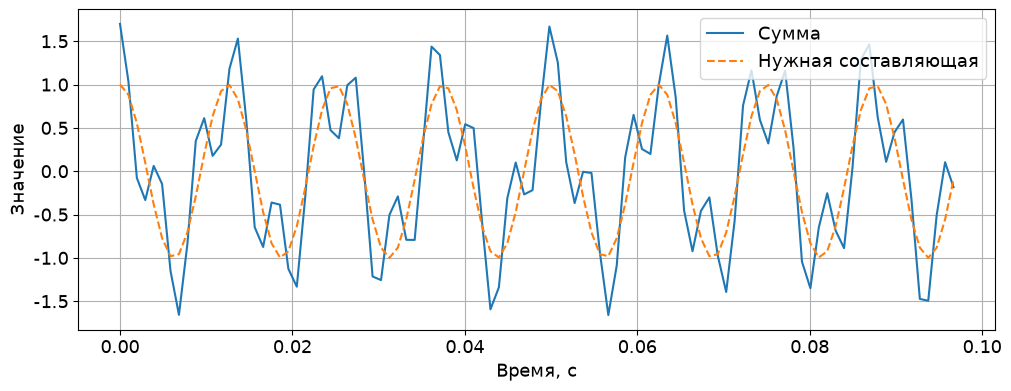

In [2]:
fs = 1024.0  # учебная частота дискретизации, Гц
n = np.arange(1024)
t = n / fs
useful = np.cos(2*np.pi*80*t)
unwanted = 0.7*np.cos(2*np.pi*220*t)
x = useful + unwanted
print('Первые отсчеты:',x[:8])
fig, ax = plt.subplots(layout='constrained')
ax.plot(t[:100],x[:100],label='Сумма')
ax.plot(t[:100],useful[:100],'--',label='Нужная составляющая')
ax.set(xlabel='Время, с',ylabel='Значение'); ax.legend()
plt.show()

In [3]:
def amplitude(values, fs, hann=False):
    values = np.asarray(values, dtype=float)
    window = np.hanning(len(values)) if hann else np.ones(len(values))
    A = np.abs(np.fft.rfft(values*window))/window.sum()
    if len(values) % 2 == 0:
        A[1:-1] *= 2
    else:
        A[1:] *= 2
    return np.fft.rfftfreq(len(values), d=1/fs), A

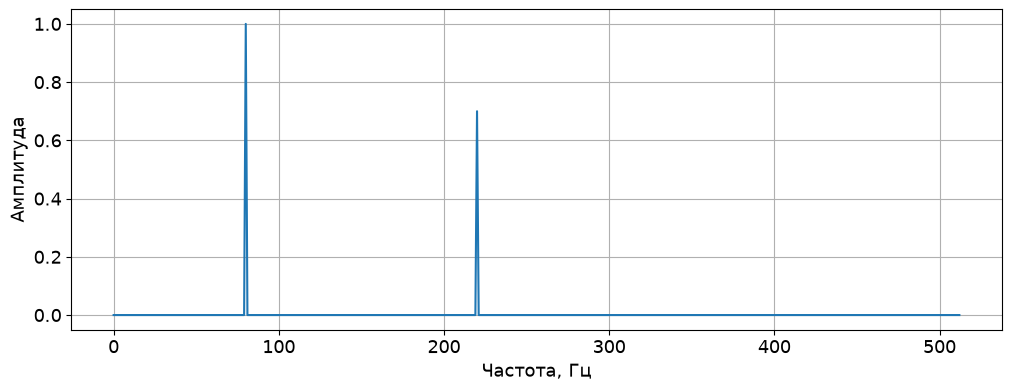

In [4]:
f, A = amplitude(x,fs)
fig, ax = plt.subplots(layout='constrained')
ax.plot(f,A)
ax.set(xlabel='Частота, Гц',ylabel='Амплитуда')
plt.show()

## 3.2 Один выходной отсчет
Коэффициенты умножаются на текущий и прошлые отсчеты

In [5]:
x_small = np.array([0.,0.,4.,0.,0.,0.])
h_small = np.array([0.25,0.5,0.25])
position = 3
recent = x_small[position-np.arange(len(h_small))]
print('Вход:',x_small)
print('Текущий и прошлые:',recent)
print('Коэффициенты:',h_small)
print('Произведения:',h_small*recent)
print('Сумма:',np.sum(h_small*recent))

Вход: [0. 0. 4. 0. 0. 0.]
Текущий и прошлые: [0. 4. 0.]
Коэффициенты: [0.25 0.5  0.25]
Произведения: [0. 2. 0.]
Сумма: 2.0


## 3.3 Свертка и причинность
Одно правило применяется в каждой позиции

lfilter: [0. 0. 1. 2. 1. 0.]
Полная свертка: [0. 0. 1. 2. 1. 0. 0. 0.]
Совпадают первые N значений: True


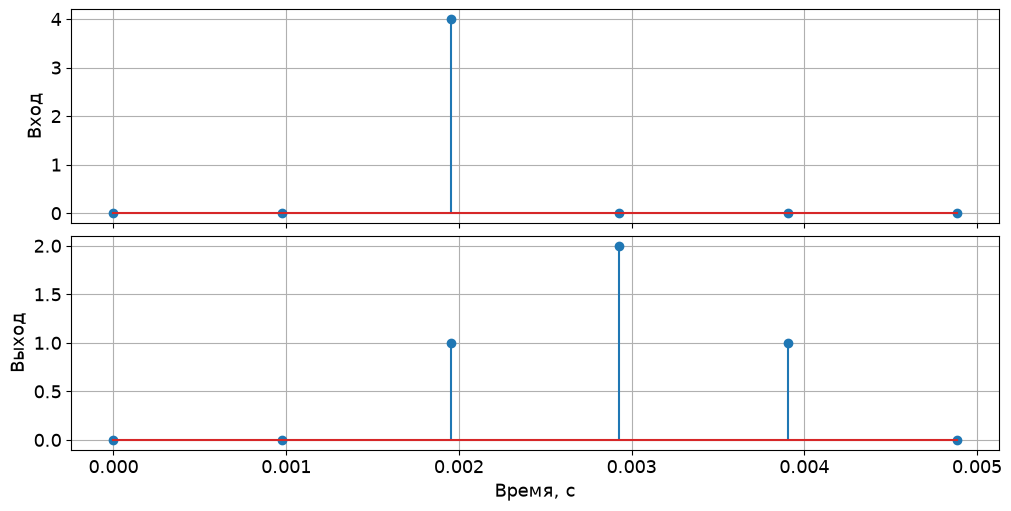

In [6]:
y_small = lfilter(h_small,[1.0],x_small)
full = np.convolve(x_small,h_small,mode='full')
print('lfilter:',y_small)
print('Полная свертка:',full)
print('Совпадают первые N значений:',np.allclose(y_small,full[:len(x_small)]))
fig, axes = plt.subplots(2,1,figsize=(10,5),sharex=True,layout='constrained')
axes[0].stem(np.arange(len(x_small))/fs,x_small)
axes[0].set(ylabel='Вход')
axes[1].stem(np.arange(len(y_small))/fs,y_small)
axes[1].set(xlabel='Время, с',ylabel='Выход')
plt.show()

## 3.4 Импульс и два семейства фильтров
КИХ: конечный отклик; БИХ: продолжающийся отклик

КИХ: [0.25 0.5  0.25 0.   0.   0.  ]
БИХ: [0.5      0.25     0.125    0.0625   0.03125  0.015625]


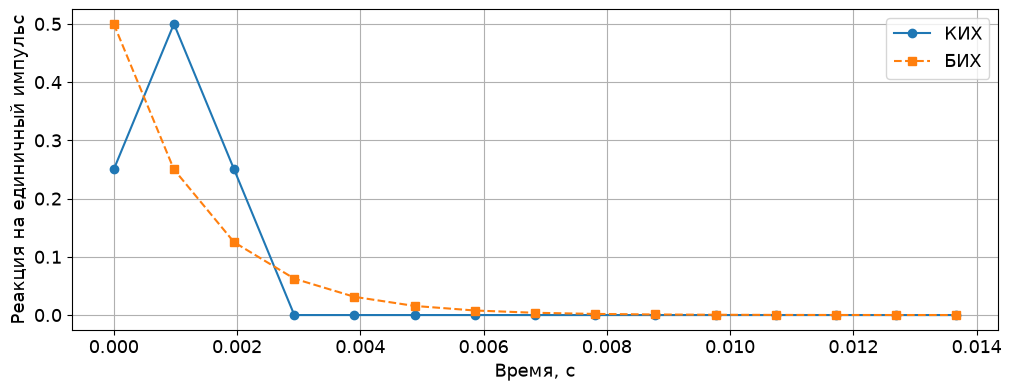

In [7]:
impulse = np.zeros(15)
impulse[0] = 1
fir_response = lfilter(h_small,[1.0],impulse)
iir_response = lfilter([0.5],[1.0,-0.5],impulse)
print('КИХ:',fir_response[:6])
print('БИХ:',iir_response[:6])
fig, ax = plt.subplots(layout='constrained')
ax.plot(np.arange(len(impulse))/fs,fir_response,'o-',label='КИХ')
ax.plot(np.arange(len(impulse))/fs,iir_response,'s--',label='БИХ')
ax.set(xlabel='Время, с',ylabel='Реакция на единичный импульс'); ax.legend()
plt.show()

## 3.5 АЧХ и выбор полосы
АЧХ описывает фильтр, спектр описывает сигнал

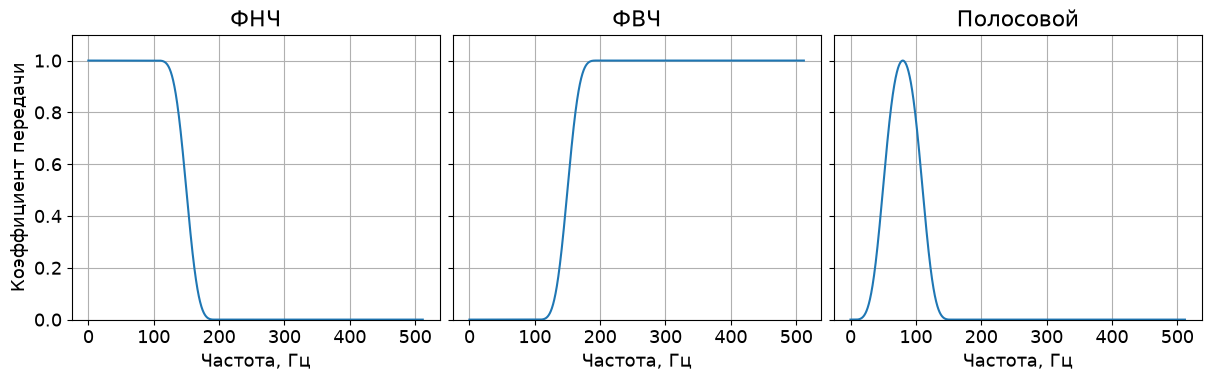

In [8]:
fig, axes = plt.subplots(1,3,figsize=(12,3.7),sharey=True,layout='constrained')
settings = [('ФНЧ',150.0,True),('ФВЧ',150.0,False),('Полосовой',[50.0,110.0],False)]
for ax,(name,cutoff,pass_zero) in zip(axes,settings):
    coefficients = firwin(65,cutoff,pass_zero=pass_zero,fs=fs,window=('kaiser',8))
    f_response,H = freqz(coefficients,fs=fs,worN=2048)
    ax.plot(f_response,np.abs(H))
    ax.set(title=name,xlabel='Частота, Гц',ylim=(0,1.1))
axes[0].set_ylabel('Коэффициент передачи')
plt.show()

## 3.6 Коэффициенты из требований

In [9]:
K = 65
band = [50.0,110.0]
h = firwin(K,band,pass_zero=False,fs=fs,window=('kaiser',8))
print('Коэффициентов:',len(h),'Порядок:',len(h)-1)
print('Первые коэффициенты:',h[:6])
frequencies = np.array([80.0,220.0])
_, gains = freqz(h,worN=frequencies,fs=fs)
print('Частоты, Гц:',frequencies)
print('Передача:',np.abs(gains))

Коэффициентов: 65 Порядок: 64
Первые коэффициенты: [ 1.82730007e-05  5.34508642e-05  8.00858013e-05  2.79730908e-05
 -1.91258736e-04 -6.17175782e-04]
Частоты, Гц: [ 80. 220.]
Передача: [1.00000000e+00 3.94427276e-06]


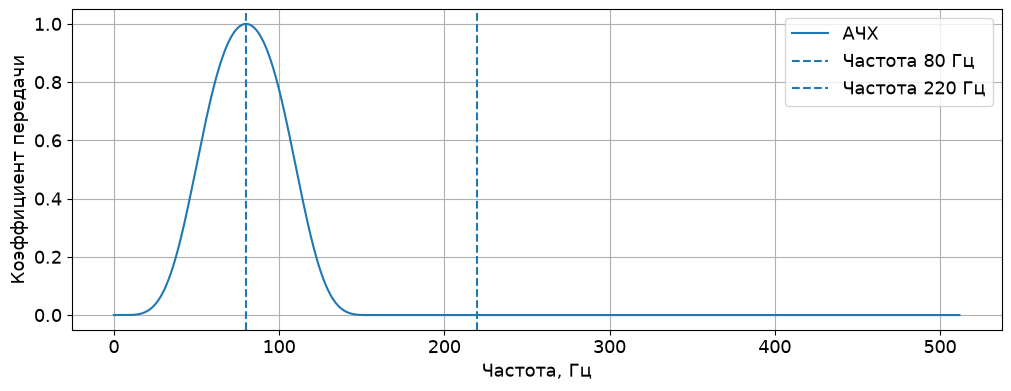

In [10]:
f_response,H = freqz(h,fs=fs,worN=2048)
fig, ax = plt.subplots(layout='constrained')
ax.plot(f_response,np.abs(H),label='АЧХ')
for f0 in frequencies:
    ax.axvline(f0,linestyle='--',label=f'Частота {f0:g} Гц')
ax.set(xlabel='Частота, Гц',ylabel='Коэффициент передачи'); ax.legend()
plt.show()

## 3.7 Выход, задержка и начало записи
Задержка 0.03125 с; начальный участок 0.0625 с

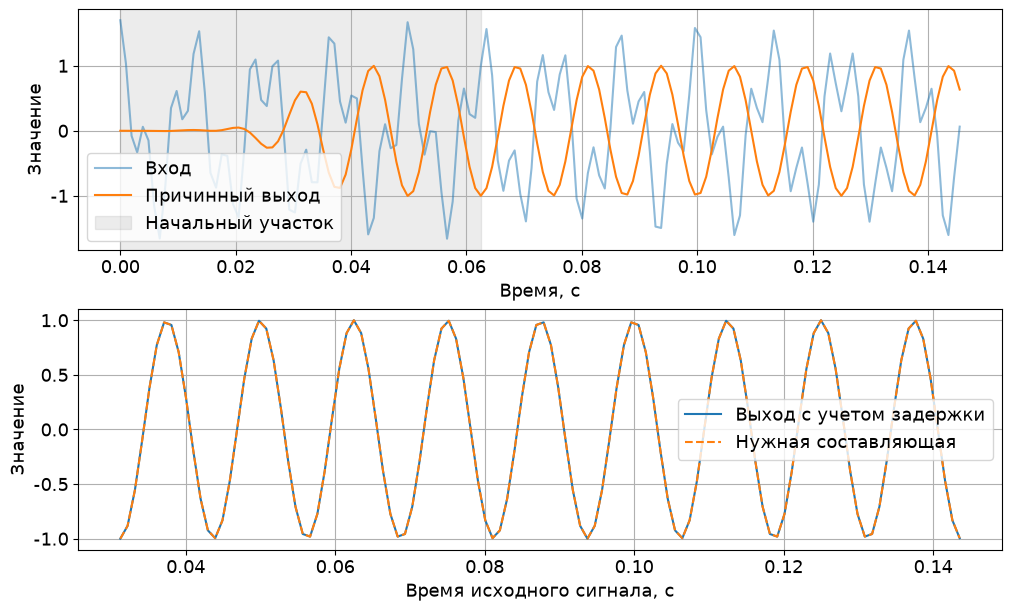

In [11]:
y = lfilter(h,[1.0],x)
delay = (K-1)//2
fig, axes = plt.subplots(2,1,figsize=(10,6),layout='constrained')
axes[0].plot(t[:150],x[:150],alpha=0.5,label='Вход')
axes[0].plot(t[:150],y[:150],label='Причинный выход')
axes[0].axvspan(0,(K-1)/fs,color='gray',alpha=0.15,label='Начальный участок')
axes[0].set(xlabel='Время, с',ylabel='Значение'); axes[0].legend()
idx = np.arange(K-1,180)
axes[1].plot((idx-delay)/fs,y[idx],label='Выход с учетом задержки')
axes[1].plot((idx-delay)/fs,useful[idx-delay],'--',label='Нужная составляющая')
axes[1].set(xlabel='Время исходного сигнала, с',ylabel='Значение'); axes[1].legend()
plt.show()

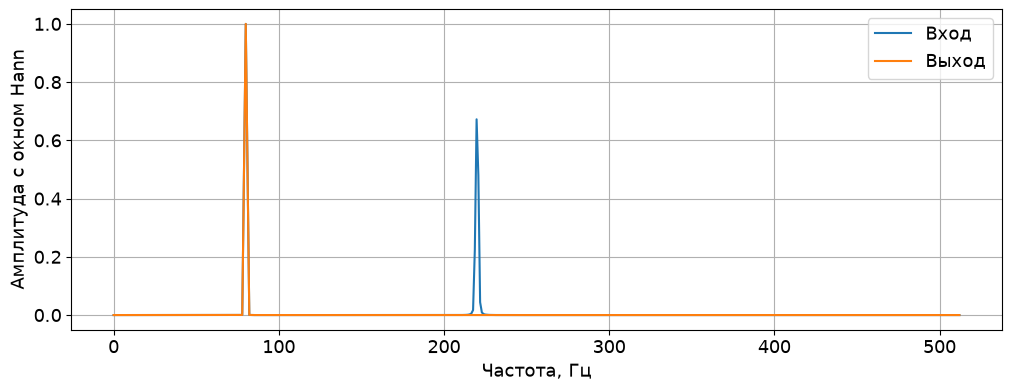

In [12]:
fig, ax = plt.subplots(layout='constrained')
for values,label in [(x[K-1:],'Вход'),(y[K-1:],'Выход')]:
    f,A = amplitude(values,fs,hann=True)
    ax.plot(f,A,label=label)
ax.set(xlabel='Частота, Гц',ylabel='Амплитуда с окном Hann'); ax.legend()
plt.show()

## 3.8 Длина фильтра и близкие пики

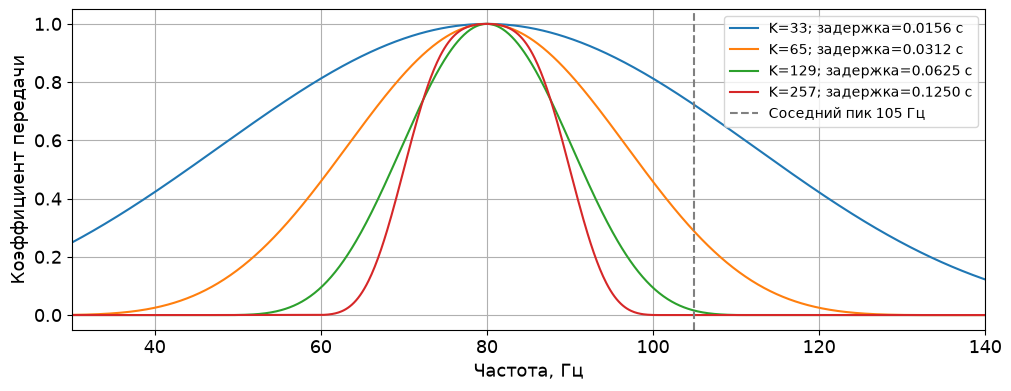

In [13]:
fig, ax = plt.subplots(layout='constrained')
for taps in (33,65,129,257):
    hh = firwin(taps,[70.0,90.0],pass_zero=False,fs=fs,window=('kaiser',8))
    ff,HH = freqz(hh,fs=fs,worN=4096)
    ax.plot(ff,np.abs(HH),label=f'K={taps}; задержка={(taps-1)/(2*fs):.4f} с')
ax.axvline(105.0,color='gray',linestyle='--',label='Соседний пик 105 Гц')
ax.set(xlabel='Частота, Гц',ylabel='Коэффициент передачи',xlim=(30,140))
ax.legend(fontsize=10)
plt.show()

In [ ]:
def response_demo(taps=65):
    hh = firwin(taps,[70.0,90.0],pass_zero=False,fs=fs,window=('kaiser',8))
    ff,HH = freqz(hh,fs=fs,worN=4096)
    fig, ax = plt.subplots(layout='constrained')
    ax.plot(ff,np.abs(HH))
    ax.axvline(105.0,color='C1',linestyle='--')
    ax.set(xlabel='Частота, Гц',ylabel='Коэффициент передачи',
           title=f'K={taps}; задержка={(taps-1)/(2*fs):.4f} с',xlim=(30,140),ylim=(0,1.1))
    plt.show()

import ipywidgets as widgets
widgets.interact(response_demo,taps=widgets.SelectionSlider(options=[33,65,129,257],value=65));

interactive(children=(SelectionSlider(description='taps', index=1, options=(33, 65, 129, 257), value=65), Outp…

## 3.9 Файл, пики и параметры фильтра
1024 числа; учебная частота дискретизации 1024 Гц

In [15]:
print('Частота дискретизации, Гц:',fs)
print('Число коэффициентов:',K)
print('Границы, Гц:',band)
print('Окно: Kaiser, beta=8')

Частота дискретизации, Гц: 1024.0
Число коэффициентов: 65
Границы, Гц: [50.0, 110.0]
Окно: Kaiser, beta=8
